# Core Exploratory Data Analysis

## DATA 698 Master's Research Capstone

**Project:** *When Severity Does Not Equal Risk: A Longitudinal Analysis of Vulnerability Severity and Real-World Exploitation*

### Purpose

This notebook performs the core exploratory analysis using the validated master analytical dataset created in `data_preparation.ipynb`.

The analysis focuses on:

1. Sensitivity of known-exploited vulnerability mismatch rates to different CVSS prioritization thresholds
2. Changes in mismatch rates by publication year
3. Differences in CVSS score and severity distributions between CISA KEV vulnerabilities and the broader NVD population

The processed master dataset is loaded directly from:

`data/processed/master_vulnerability_dataset.csv`

The 2026 data represents an incomplete year and is interpreted separately in longitudinal comparisons.

In [1]:
# Imports and project paths

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)

# Locate project root
cwd = Path.cwd().resolve()

if (cwd / "data").exists() and (cwd / "notebooks").exists():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the data698-capstone project root."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

MASTER_DATA_FILE = (
    PROCESSED_DIR / "master_vulnerability_dataset.csv"
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Master dataset exists:", MASTER_DATA_FILE.exists())

Master dataset exists: True


In [2]:
# Load validated master analytical dataset

df = pd.read_csv(
    MASTER_DATA_FILE,
    parse_dates=[
        "published",
        "last_modified",
        "kev_date_added"
    ]
)

print("Dataset shape:", df.shape)
print("Unique CVEs:", f"{df['cve'].nunique():,}")
print("KEV vulnerabilities:", f"{df['kev_flag'].sum():,}")

Dataset shape: (239942, 38)
Unique CVEs: 239,942
KEV vulnerabilities: 1,139


## 1. CVSS Threshold Sensitivity Analysis

Severity-based prioritization can produce different results depending on the CVSS cutoff used to determine which vulnerabilities receive priority.

This analysis evaluates multiple hypothetical CVSS prioritization thresholds and calculates the number and percentage of known-exploited vulnerabilities that fall below each cutoff.

A KEV vulnerability below a given threshold represents a potential severity-based prioritization mismatch: the vulnerability has documented real-world exploitation but would fall below that hypothetical CVSS prioritization cutoff.

Only KEV vulnerabilities with an available CVSS score are included in the denominator.

In [3]:
# Known-exploited vulnerabilities with usable CVSS scores

kev_cvss = df.loc[
    df["kev_flag"]
    & df["cvss_score"].notna()
].copy()

print(
    "KEV vulnerabilities with CVSS:",
    f"{len(kev_cvss):,}"
)

KEV vulnerabilities with CVSS: 1,138


In [4]:
# Threshold sensitivity analysis

thresholds = [6, 7, 8, 9]

threshold_results = []

for threshold in thresholds:

    below_threshold = (
        kev_cvss["cvss_score"] < threshold
    )

    count = int(below_threshold.sum())

    percent = (
        count
        / len(kev_cvss)
        * 100
    )

    threshold_results.append({
        "cvss_threshold": threshold,
        "kev_with_cvss": len(kev_cvss),
        "below_threshold": count,
        "percent_below_threshold": percent
    })


threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df["percent_below_threshold"] = (
    threshold_results_df["percent_below_threshold"]
    .round(2)
)

display(threshold_results_df)

,cvss_threshold,kev_with_cvss,below_threshold,percent_below_threshold
0,6,1138,77,6.77
1,7,1138,138,12.13
2,8,1138,474,41.65
3,9,1138,694,60.98


In [6]:
# Beautify threshold results table

threshold_table = (
    threshold_results_df
    .rename(
        columns={
            "cvss_threshold": "CVSS Cutoff",
            "kev_with_cvss": "KEVs with CVSS",
            "below_threshold": "KEVs Below Cutoff",
            "percent_below_threshold": "Percent Below Cutoff"
        }
    )
)

threshold_table["CVSS Cutoff"] = (
    "< " + threshold_table["CVSS Cutoff"].astype(str)
)

threshold_table["Percent Below Cutoff"] = (
    threshold_table["Percent Below Cutoff"]
    .map(lambda x: f"{x:.2f}%")
)

display(threshold_table)

,CVSS Cutoff,KEVs with CVSS,KEVs Below Cutoff,Percent Below Cutoff
0,< 6,1138,77,6.77%
1,< 7,1138,138,12.13%
2,< 8,1138,474,41.65%
3,< 9,1138,694,60.98%


In [7]:
threshold_results_file = (
    RESULTS_DIR / "threshold_sensitivity_results.csv"
)

threshold_results_df.to_csv(
    threshold_results_file,
    index=False
)

print(
    "Threshold results saved to:",
    threshold_results_file
)

Threshold results saved to: /Users/aaliyahmjh/Documents/data698-capstone/results/threshold_sensitivity_results.csv


## 2. Threshold Sensitivity Visualization

This section visualizes how the percentage of known-exploited vulnerabilities that fall below a hypothetical CVSS prioritization cutoff changes as the cutoff becomes more restrictive.

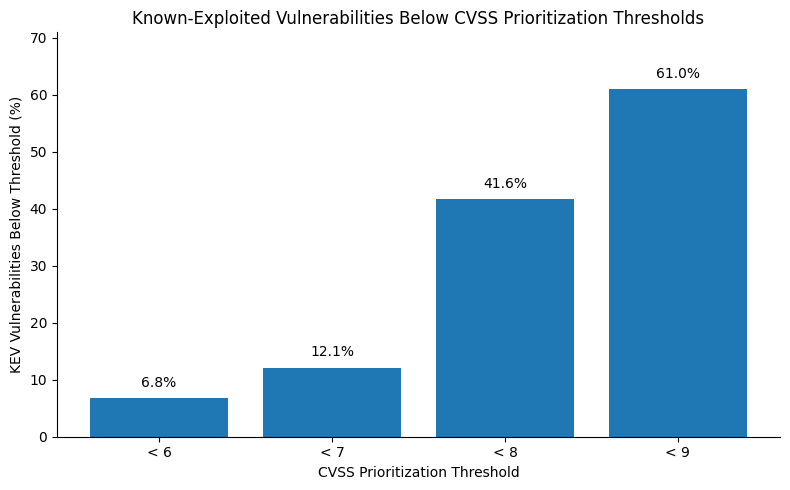

Threshold figure saved to: /Users/aaliyahmjh/Documents/data698-capstone/figures/threshold_sensitivity.png


In [11]:
# Threshold sensitivity visualization

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(threshold_results_df))

bars = ax.bar(
    x,
    threshold_results_df["percent_below_threshold"]
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"< {threshold}"
        for threshold in threshold_results_df["cvss_threshold"]
    ]
)

for bar, pct in zip(
    bars,
    threshold_results_df["percent_below_threshold"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title(
    "Known-Exploited Vulnerabilities Below CVSS Prioritization Thresholds"
)

ax.set_xlabel("CVSS Prioritization Threshold")
ax.set_ylabel("KEV Vulnerabilities Below Threshold (%)")

ax.set_ylim(
    0,
    threshold_results_df["percent_below_threshold"].max() + 10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

threshold_figure_file = (
    FIGURES_DIR / "threshold_sensitivity.png"
)

plt.savefig(
    threshold_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Threshold figure saved to:",
    threshold_figure_file
)

### Interpretation

The threshold sensitivity analysis shows that the estimated degree of under-prioritization depends substantially on the CVSS cutoff used.

Among 1,138 KEV vulnerabilities with available CVSS scores:

- **6.77%** have CVSS scores below 6.0.
- **12.13%** fall below 7.0.
- **41.65%** fall below 8.0.
- **60.98%** fall below 9.0.

The increasing mismatch rate at higher cutoffs illustrates the sensitivity of severity-based prioritization to the threshold selected. In particular, a strategy focused only on vulnerabilities with CVSS scores of 9.0 or higher would exclude a substantial share of vulnerabilities with documented real-world exploitation.

These results describe potential prioritization mismatches under hypothetical CVSS cutoffs; they do not imply that organizations universally use these thresholds as their sole remediation criteria.

## 3. Yearly Mismatch Patterns

The overall threshold analysis shows how sensitive potential under-prioritization is to the selected CVSS cutoff. This section examines whether those patterns differ across publication years.

For each year from 2020 through 2026, the analysis calculates the percentage of known-exploited vulnerabilities with available CVSS scores that fall below the 7.0, 8.0, and 9.0 thresholds.

The denominator for each year is the number of KEV vulnerabilities published in that year with an available CVSS score.

Because the 2026 data represents an incomplete year, 2026 results are reported but should not be interpreted as directly comparable with complete prior years.

In [12]:
# Year-by-year threshold mismatch analysis

yearly_results = []

yearly_thresholds = [7, 8, 9]

for year in sorted(kev_cvss["publication_year"].unique()):

    year_data = kev_cvss.loc[
        kev_cvss["publication_year"] == year
    ]

    total_kev = len(year_data)

    for threshold in yearly_thresholds:

        below_count = int(
            (year_data["cvss_score"] < threshold).sum()
        )

        below_percent = (
            below_count / total_kev * 100
            if total_kev > 0
            else np.nan
        )

        yearly_results.append({
            "publication_year": int(year),
            "cvss_threshold": threshold,
            "kev_with_cvss": total_kev,
            "below_threshold": below_count,
            "percent_below_threshold": below_percent
        })


yearly_results_df = pd.DataFrame(yearly_results)

yearly_results_df[
    "percent_below_threshold"
] = yearly_results_df[
    "percent_below_threshold"
].round(2)

display(yearly_results_df)

,publication_year,cvss_threshold,kev_with_cvss,below_threshold,percent_below_threshold
0,2020,7,136,16,11.76
1,2020,8,136,55,40.44
2,2020,9,136,79,58.09
3,2021,7,214,28,13.08
4,2021,8,214,100,46.73
5,2021,9,214,146,68.22
6,2022,7,130,16,12.31
7,2022,8,130,56,43.08
8,2022,9,130,83,63.85
9,2023,7,164,24,14.63


In [13]:
# Create year-by-year mismatch rate table

yearly_rate_table = (
    yearly_results_df
    .pivot(
        index="publication_year",
        columns="cvss_threshold",
        values="percent_below_threshold"
    )
    .rename(
        columns={
            7: "Below 7 (%)",
            8: "Below 8 (%)",
            9: "Below 9 (%)"
        }
    )
    .reset_index()
)

yearly_rate_table = yearly_rate_table.rename(
    columns={
        "publication_year": "Publication Year"
    }
)

display(yearly_rate_table)

cvss_threshold,Publication Year,Below 7 (%),Below 8 (%),Below 9 (%)
0,2020,11.76,40.44,58.09
1,2021,13.08,46.73,68.22
2,2022,12.31,43.08,63.85
3,2023,14.63,48.78,69.51
4,2024,9.38,42.50,56.88
5,2025,12.31,38.46,60.51
6,2026,10.79,28.78,45.32


In [14]:
# Add yearly KEV sample size

yearly_sample_size = (
    yearly_results_df
    .groupby("publication_year")["kev_with_cvss"]
    .first()
    .reset_index()
    .rename(
        columns={
            "publication_year": "Publication Year",
            "kev_with_cvss": "KEVs with CVSS"
        }
    )
)

yearly_rate_table = yearly_sample_size.merge(
    yearly_rate_table,
    on="Publication Year",
    how="left"
)

display(yearly_rate_table)

,Publication Year,KEVs with CVSS,Below 7 (%),Below 8 (%),Below 9 (%)
0,2020,136,11.76,40.44,58.09
1,2021,214,13.08,46.73,68.22
2,2022,130,12.31,43.08,63.85
3,2023,164,14.63,48.78,69.51
4,2024,160,9.38,42.50,56.88
5,2025,195,12.31,38.46,60.51
6,2026,139,10.79,28.78,45.32


In [15]:
yearly_results_file = (
    RESULTS_DIR / "yearly_mismatch_results.csv"
)

yearly_results_df.to_csv(
    yearly_results_file,
    index=False
)

print(
    "Yearly mismatch results saved to:",
    yearly_results_file
)

Yearly mismatch results saved to: /Users/aaliyahmjh/Documents/data698-capstone/results/yearly_mismatch_results.csv


## 4. Yearly Mismatch Trend Visualization

This section visualizes how potential CVSS-based prioritization mismatch rates change across publication years.

The 2026 results are included for completeness but are interpreted separately because 2026 represents an incomplete observation year.

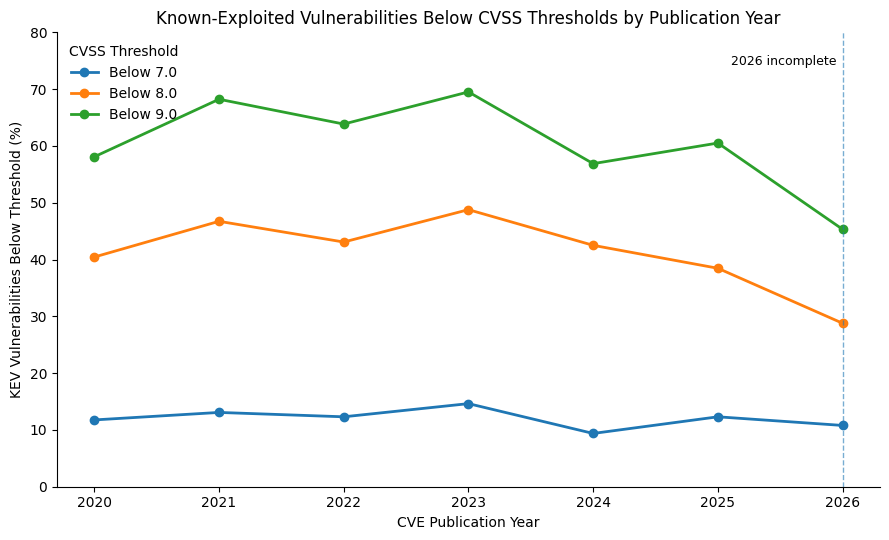

Yearly trend figure saved to: /Users/aaliyahmjh/Documents/data698-capstone/figures/yearly_mismatch_trends.png


<Figure size 640x480 with 0 Axes>

Yearly trend figure saved to: /Users/aaliyahmjh/Documents/data698-capstone/figures/yearly_mismatch_trends.png


In [18]:
# Yearly mismatch trend visualization

fig, ax = plt.subplots(figsize=(9, 5.5))

for threshold in yearly_thresholds:

    plot_data = yearly_results_df.loc[
        yearly_results_df["cvss_threshold"] == threshold
    ]

    ax.plot(
        plot_data["publication_year"],
        plot_data["percent_below_threshold"],
        marker="o",
        linewidth=2,
        label=f"Below {threshold}.0"
    )

ax.set_title(
    "Known-Exploited Vulnerabilities Below CVSS Thresholds by Publication Year"
)

ax.set_xlabel("CVE Publication Year")
ax.set_ylabel("KEV Vulnerabilities Below Threshold (%)")

ax.set_xticks(
    sorted(yearly_results_df["publication_year"].unique())
)

ax.set_ylim(0, 80)

ax.legend(
    title="CVSS Threshold",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

yearly_figure_file = (
    FIGURES_DIR / "yearly_mismatch_trends.png"
)
# Mark 2026 as an incomplete observation year
ax.axvline(
    x=2026,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.text(
    2025.95,
    76,
    "2026 incomplete",
    ha="right",
    va="top",
    fontsize=9
)

plt.tight_layout()

yearly_figure_file = (
    FIGURES_DIR / "yearly_mismatch_trends.png"
)

plt.savefig(
    yearly_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Yearly trend figure saved to:",
    yearly_figure_file
)

plt.savefig(
    yearly_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Yearly trend figure saved to:",
    yearly_figure_file
)

### Interpretation

Mismatch rates vary across publication years and across the CVSS thresholds evaluated.

For the complete years 2020–2025, the percentage of known-exploited vulnerabilities below 7.0 remains relatively stable, ranging from **9.38% to 14.63%**. Larger differences appear at the higher thresholds. The percentage below 8.0 ranges from **38.46% to 48.78%**, while the percentage below 9.0 ranges from **56.88% to 69.51%**.

Among the complete years, **2023 has the highest observed mismatch rate at each of the three thresholds**, with 14.63% of KEVs below 7.0, 48.78% below 8.0, and 69.51% below 9.0.

The 2026 mismatch rates are lower across all three thresholds; however, 2026 represents an incomplete observation year and should not be interpreted as evidence of a sustained decline.

Overall, the year-to-year results reinforce the threshold sensitivity finding: the estimated share of known-exploited vulnerabilities potentially under-prioritized by severity-only rules depends strongly on the CVSS cutoff selected.

## 5. CVSS Distribution: KEV vs. Non-KEV Vulnerabilities

The threshold analyses focus specifically on known-exploited vulnerabilities. This section broadens the comparison by examining whether CVSS severity differs between vulnerabilities listed in the CISA Known Exploited Vulnerabilities (KEV) Catalog and other vulnerabilities in the NVD analytical population.

To keep the comparison groups mutually exclusive:

- **KEV** represents vulnerabilities matched to the CISA KEV Catalog.
- **Non-KEV** represents vulnerabilities in the NVD analytical population that are not present in the KEV Catalog.

Only vulnerabilities with an available CVSS score are included in the score-distribution comparison.

Because absence from the KEV Catalog does not establish that a vulnerability has never been exploited, the non-KEV group should be interpreted as vulnerabilities without documented KEV status rather than as confirmed non-exploited vulnerabilities.

In [19]:
# Prepare CVSS distribution comparison

cvss_comparison = df.loc[
    df["cvss_score"].notna()
].copy()

cvss_comparison["group"] = np.where(
    cvss_comparison["kev_flag"],
    "KEV",
    "Non-KEV"
)

group_counts = (
    cvss_comparison["group"]
    .value_counts()
)

display(group_counts)

group
Non-KEV    228902
KEV          1138
Name: count, dtype: int64

In [20]:
# CVSS descriptive statistics by KEV status

cvss_summary = (
    cvss_comparison
    .groupby("group")["cvss_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

cvss_summary[
    ["mean", "median", "std", "minimum", "maximum"]
] = cvss_summary[
    ["mean", "median", "std", "minimum", "maximum"]
].round(2)

display(cvss_summary)

,group,count,mean,median,std,minimum,maximum
0,KEV,1138,8.42,8.8,1.39,2.7,10.0
1,Non-KEV,228902,7.01,7.2,1.71,0.0,10.0


In [21]:
# CVSS severity distribution by KEV status

severity_order = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "CRITICAL"
]

severity_counts = (
    cvss_comparison
    .groupby(["group", "cvss_severity"])
    .size()
    .reset_index(name="count")
)

severity_counts["percent"] = (
    severity_counts["count"]
    / severity_counts.groupby("group")["count"].transform("sum")
    * 100
)

severity_counts["percent"] = (
    severity_counts["percent"].round(2)
)

severity_table = (
    severity_counts
    .pivot(
        index="cvss_severity",
        columns="group",
        values="percent"
    )
    .reindex(severity_order)
)

display(severity_table)

group,KEV,Non-KEV
cvss_severity,,
LOW,0.26,2.48
MEDIUM,11.86,44.29
HIGH,48.86,39.40
CRITICAL,39.02,13.83


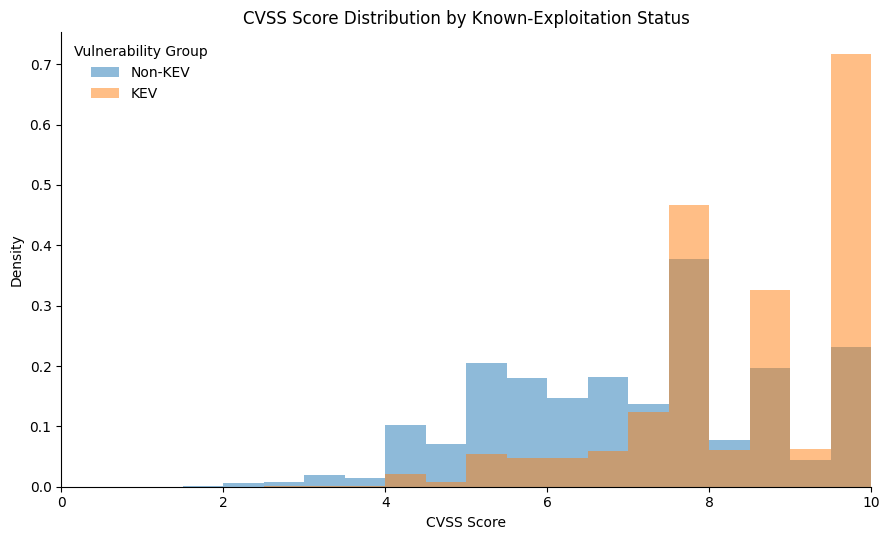

CVSS distribution figure saved to: /Users/aaliyahmjh/Documents/data698-capstone/figures/cvss_distribution_kev_vs_nonkev.png


In [22]:
# CVSS score distribution visualization

kev_scores = cvss_comparison.loc[
    cvss_comparison["group"] == "KEV",
    "cvss_score"
]

nonkev_scores = cvss_comparison.loc[
    cvss_comparison["group"] == "Non-KEV",
    "cvss_score"
]

bins = np.arange(0, 10.5, 0.5)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    nonkev_scores,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Non-KEV"
)

ax.hist(
    kev_scores,
    bins=bins,
    density=True,
    alpha=0.5,
    label="KEV"
)

ax.set_title(
    "CVSS Score Distribution by Known-Exploitation Status"
)

ax.set_xlabel("CVSS Score")
ax.set_ylabel("Density")

ax.set_xlim(0, 10)

ax.legend(
    title="Vulnerability Group",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

cvss_distribution_file = (
    FIGURES_DIR / "cvss_distribution_kev_vs_nonkev.png"
)

plt.savefig(
    cvss_distribution_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "CVSS distribution figure saved to:",
    cvss_distribution_file
)

In [23]:
cvss_summary_file = (
    RESULTS_DIR / "cvss_distribution_summary.csv"
)

severity_results_file = (
    RESULTS_DIR / "cvss_severity_distribution.csv"
)

cvss_summary.to_csv(
    cvss_summary_file,
    index=False
)

severity_counts.to_csv(
    severity_results_file,
    index=False
)

print("CVSS summary saved to:", cvss_summary_file)
print("Severity distribution saved to:", severity_results_file)

CVSS summary saved to: /Users/aaliyahmjh/Documents/data698-capstone/results/cvss_distribution_summary.csv
Severity distribution saved to: /Users/aaliyahmjh/Documents/data698-capstone/results/cvss_severity_distribution.csv


### Interpretation

Known-exploited vulnerabilities generally have higher CVSS scores than vulnerabilities without documented KEV status.

Among vulnerabilities with available CVSS scores, the **KEV group has a mean CVSS score of 8.42 and a median of 8.8**, compared with a **mean of 7.01 and median of 7.2** for the non-KEV group. The distribution figure similarly shows that KEV vulnerabilities are more concentrated toward the higher end of the CVSS scale.

The categorical severity distribution reinforces this pattern. **87.88% of KEV vulnerabilities are classified as High or Critical**, including 39.02% classified as Critical. In comparison, **53.23% of non-KEV vulnerabilities are High or Critical**, with 13.83% classified as Critical.

These descriptive results indicate that known-exploited vulnerabilities tend to have higher technical severity overall. However, the distributions overlap substantially, and not all known-exploited vulnerabilities receive very high CVSS scores. This is consistent with the threshold sensitivity analysis, which found that **12.13% of KEVs with available CVSS scores fall below 7.0 and 60.98% fall below 9.0**.

Together, these findings suggest that CVSS severity contains useful information about known exploitation status but does not perfectly separate known-exploited vulnerabilities from other vulnerabilities. Further statistical analysis is needed to evaluate the strength and significance of these relationships.